In [7]:
import netCDF4
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rasterio
import pyproj

import helpers
import numpy as np



In [2]:
# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/LULC/WorldCover_LULC_Brussels.tif')
# Read the image data from the GeoTIFF file
image = src.read()
#projection_tif = ccrs.epsg(src.crs.to_epsg())
# Get the extent of the image
extent_4326 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print(extent_4326)
src.close()

image[0].shape

(7200, 12000)

# Create LULC map of WorldCover dataset

extent_meteo3035:  [3081555.0, 3111555.0, 3910061.0, 3940061.0]
extent_meteo4326:  [50.698475, 50.98796, 4.1430073, 4.6004033]
EPSG:4258
12000
7200
[4.0, 5.0, 50.5, 51.1]
clip_3035 [3082000, 3111000, 3911000, 3940000]
extent_meteo4326 [4.1430073, 4.6004033, 50.698475, 50.98796]
clip [1344, 4819, 1716, 7205]
image.shape:  (7200, 12000)


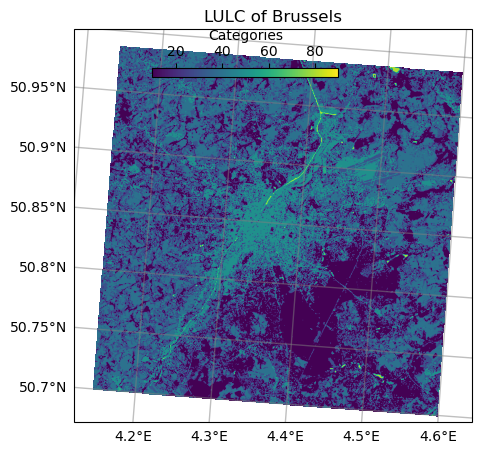

In [3]:
# Open the netCDF file
ncfile5 = netCDF4.Dataset('./data/meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_2015_06_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
extent_meteo3035 = [y.min(), y.max(), x.min(), x.max() ]
extent_meteo4326 = [lats.min(), lats.max(), lons.min(), lons.max() ]
print('extent_meteo3035: ',extent_meteo3035)
print('extent_meteo4326: ',extent_meteo4326)
ncfile5.close()

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/LULC/WorldCover_LULC_Brussels.tif')#probably not EPSG4326 doesn't match 
# Read the image data from the GeoTIFF file
image = src.read()[0]
print(src.crs)
print(src.width)
print(src.height)
extent_lulc4326 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print(extent_lulc4326)

clip_3035, clip, y_int, x_int = helpers.clip_city(extent_meteo3035, extent_meteo3035, 10) 
print('clip_3035',clip_3035)
#this clip is wrong. We need to calculate the correct clip with the clip_3035 we got from this step.
extent_meteo4326 = [extent_meteo4326[2], extent_meteo4326[3], extent_meteo4326[0], extent_meteo4326[1]]
print('extent_meteo4326',extent_meteo4326)
clip = [ int(np.floor((extent_lulc4326[3]-extent_meteo4326[3])*12000)), int(np.ceil((extent_lulc4326[3]-extent_meteo4326[2])*12000)),
        int(np.floor((extent_meteo4326[0]-extent_lulc4326[0])*12000)), int(np.ceil((extent_meteo4326[1]-extent_lulc4326[0])*12000))]
#clip = [1404, 4763, 2274, 6825]

print('clip',clip)
print('image.shape: ',image.shape)
data2 = image[clip[0]:clip[1], clip[2]:clip[3]]


# Create a figure and axis with specified CRS
projection = ccrs.epsg(3035)
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(6, 6))

# Add coastlines and title
#ax.coastlines()
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
plt.title('LULC of Brussels')

# Add colorbar
im = ax.imshow(data2, extent=[extent_meteo4326[0], extent_meteo4326[1], extent_meteo4326[2],extent_meteo4326[3]], transform=ccrs.PlateCarree(), cmap='viridis', origin='upper')
plt.colorbar(im, ax=ax,location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8), label='Categories')
# Add coastlines
#ax.coastlines()
# Add gridlines with correct longitude and latitude markings
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Show the plot
plt.show()

In [4]:
#I have to find the center points of all grids in the origional dataset (EPSG4326) and project the coordinates of the grids into EPSG3035. 
#Then check if the grids are in the certain EPSG3035 grids

In [5]:
# Open the netCDF file
ncfile5 = netCDF4.Dataset('./data/Meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_2015_06_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]

extent_meteo = [y.min(), y.max(), x.min(), x.max() ]

print('extent_meteo: ',extent_meteo)
ncfile5.close()

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/LULC/WorldCover_10m_Belgium.tif')#probably not EPSG4326 doesn't match 
# Read the image data from the GeoTIFF file
image = src.read()[0]
#print(src.crs)
#print(src.width)
#print(src.height)
extent_lulc4326 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print('extent_lulc4326: ',extent_lulc4326)

clip_3035, clip, y_int, x_int = helpers.clip_city(extent_meteo, extent_meteo, 10) 
print('clip_3035',clip_3035)
#this clip is wrong. We need to calculate the correct clip with the clip_3035 we got from this step.
extent_meteo4326 = [extent_meteo4326[2], extent_meteo4326[3], extent_meteo4326[0], extent_meteo4326[1]]
print('extent_meteo4326',extent_meteo4326)
clip = [ int(np.floor((extent_lulc4326[3]-extent_meteo4326[3])*12000)), int(np.ceil((extent_lulc4326[3]-extent_meteo4326[2])*12000)),
        int(np.floor((extent_meteo4326[0]-extent_lulc4326[0])*12000)), int(np.ceil((extent_meteo4326[1]-extent_lulc4326[0])*12000))]
src.close()
clip_3035 = [clip_3035[0], clip_3035[1], clip_3035[2], clip_3035[3]]

Ys_lulc4326, Xs_lulc4326 = helpers.GetCentroids(yLims=[src.bounds.bottom, src.bounds.top], xLims=[src.bounds.left, src.bounds.right], shapeYX=(src.height,src.width))
Ys_lulc3035, Xs_lulc3035 = helpers.GetGrids(yLims=[clip_3035[0]*1000, clip_3035[1]*1000], xLims=[clip_3035[2]*1000, clip_3035[3]*1000], shapeYX=(clip_3035[1]- clip_3035[0],clip_3035[3]- clip_3035[2]))
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
print('clip_3035',clip_3035)
classes = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100])
new_classes = ['Tree','Shrubland','Grassland','Cropland','Built-up', 'Bare', 'Snow', 'water', 'Wetland', 'Mangroves', 'Moss&lichen']

lulc_nc = np.zeros((len(classes),y_int, x_int))
print(lulc_nc.shape)


extent_meteo:  [3081555.0, 3111555.0, 3910061.0, 3940061.0]
extent_lulc4326:  [2.0, 7.0, 49.0, 52.0]
clip_3035 [3082000, 3111000, 3911000, 3940000]
extent_meteo4326 [50.698475, 50.98796, 4.1430073, 4.6004033]
clip_3035 [3082000, 3111000, 3911000, 3940000]
(11, 29, 29)


In [ ]:
l=0
Ys_lulc4326 = Ys_lulc4326[::-1] #y_index counts from the top.
for y_4326 in Ys_lulc4326:

    for x_4326 in Xs_lulc4326:
        x_3035, y_3035 = transformer.transform(x_4326, y_4326)
        if y_3035 <= np.min(Ys_lulc3035) or y_3035 >= np.max(Ys_lulc3035) or x_3035 <= np.min(Xs_lulc3035) or x_3035 >= np.max(Xs_lulc3035):
            a=0
        else:
            l=l+1
            y_index3035 = np.searchsorted(Ys_lulc3035, y_3035) - 1
            x_index3035 = np.searchsorted(Xs_lulc3035, x_3035) - 1
            y_index4326 = np.where(Ys_lulc4326 == y_4326)[0][0]
            x_index4326 = np.where(Xs_lulc4326 == x_4326)[0][0]

            #print('y_index4326,x_index4326: ',y_index4326,x_index4326)
            #print('image[y_index4326][x_index4326]: ',image[y_index4326][x_index4326])
            lulc_nc[np.where(classes == image[y_index4326][x_index4326])[0][0]][y_index3035, x_index3035] = lulc_nc[np.where(classes == image[y_index4326][x_index4326])[0][0]][y_index3035, x_index3035]+1

lulc = lulc_nc/np.sum(lulc_nc,axis=0)

In [ ]:
lulc = lulc[:,::-1,:]

#creat grid indexes with centroid of the grids
y_new = np.array((np.arange(clip_3035[0]+500, clip_3035[1]+500, 1000)))[::-1]
x_new = np.array((np.arange(clip_3035[2]+500, clip_3035[3]+500, 1000)))
print(y_new)
print(y_new.shape)
print(x_new)
print(x_new.shape)
lons = np.zeros((y_new.shape[0], x_new.shape[0]))
lats = np.zeros((y_new.shape[0], x_new.shape[0]))
EPSG_from = 3035
EPSG_to = 4326
crs_from = pyproj.CRS('EPSG:'+str(EPSG_from))  # ETRS89 / LAEA Europe
crs_to = pyproj.CRS('EPSG:'+str(EPSG_to))    # WGS 84

# Create a transformer to convert coordinates
transformer = pyproj.Transformer.from_crs(crs_from, crs_to, always_xy=True)

for x in x_new:
    for y in y_new:
        x_loc = np.where(x_new==x)[0]
        y_loc = np.where(y_new==y)[0]
        lons[y_loc, x_loc], lats[len(y_new) - y_loc-1, x_loc] = transformer.transform(x, y)
print(lons)
print(lats)

(11, 29, 29)


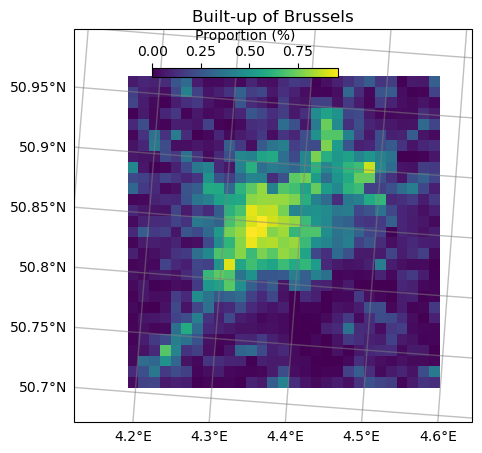

In [18]:
# Create a figure and axis with specified CRS
projection = ccrs.epsg(3035)
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(6, 6))

plt.title('Built-up of Brussels')
print(lulc.shape)

# Plot the data using pcolormesh
#Ys, Xs = helpers.GetCentroids(yLims=[clip_3035[0]*1000, clip_3035[1]*1000], xLims=[clip_3035[2]*1000, clip_3035[3]*1000], shapeYX=(clip_3035[1]- clip_3035[0],clip_3035[3]- clip_3035[2]))
#Ys = Ys[::-1]
plt.pcolormesh(x_new, y_new, lulc_nc[12]).set_clim(0,1)
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(label='Proportion (%)',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8))


# Show the plot
plt.show()

In [24]:
#save the results in a nc file
OutputFile = netCDF4.Dataset('./data/LULC/WorldCover_Brussels_11bands.nc', "w", format="NETCDF4")


len1 = OutputFile.createDimension("x", x_int)
len2 = OutputFile.createDimension("y", y_int)

y = y_new.copy()
x = x_new.copy()

var_x = OutputFile.createVariable("x", "f4", ("x",))
var_y = OutputFile.createVariable("y", "f4", ("y",))
var_lons = OutputFile.createVariable('longitude', "f4", ("y","x"))
var_lats = OutputFile.createVariable('latitude', "f4", ("y","x"))
for i in range(len(classes)):
    var = OutputFile.createVariable(new_classes[i], "f4", ("y","x"))
    var[:] = lulc[i]

var_x[:] = x
var_y[:] = y
var_lons[:] = lons
var_lats[:] = lats
OutputFile.close()

In [23]:
OutputFile.close()

(11, 29, 29)
clip_3035 [3082, 3111, 3911, 3940]
(29,)


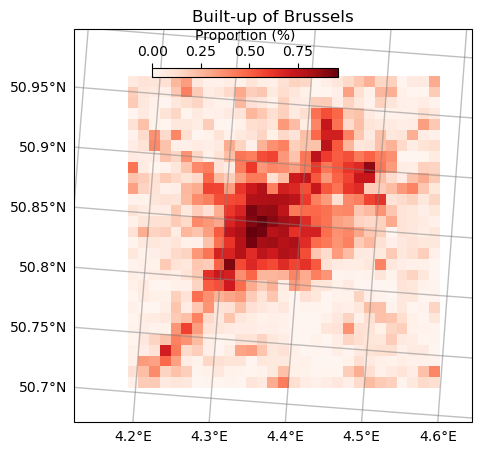

In [29]:
# Create a figure and axis with specified CRS
projection = ccrs.epsg(3035)
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(6, 6))

plt.title('Built-up of Brussels')
print(lulc.shape)
print('clip_3035',clip_3035)
clip_3035new = [clip_3035[0], clip_3035[1], clip_3035[2], clip_3035[3]]

# Plot the data using pcolormesh
Ys, Xs = helpers.GetCentroids(yLims=[clip_3035new[0]*1000, clip_3035new[1]*1000], xLims=[clip_3035new[2]*1000, clip_3035new[3]*1000], shapeYX=(clip_3035new[1]- clip_3035new[0],clip_3035new[3]- clip_3035new[2]))
print(Ys.shape)
#Ys = Ys[::-1]
plt.pcolormesh(Xs, Ys, lulc[4], cmap='Reds')
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(label='Proportion (%)',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8))


# Show the plot
plt.show()

In [16]:
from pyproj import Transformer
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
#x_3035, y_3035 = transformer.transform(x_4326, y_4326)
#transformer = Transformer.from_crs("epsg:4326", "epsg:3035")
x_min_3035, y_min_3035 = transformer.transform(4, 50.5)
x_max_3035, y_max_3035 = transformer.transform(5, 51.1)

print("Reprojected Coordinates using pyproj:")
print(f"x_min: {x_min_3035}, y_min: {y_min_3035}")
print(f"x_max: {x_max_3035}, y_max: {y_max_3035}")



import geopandas as gpd
from shapely.geometry import Point
d = {'col1': ['name1', 'name2'], 'geometry': [Point(4, 50.5), Point(5, 51.1)]}
gdf = gpd.GeoDataFrame(d, crs='epsg:4326')
gdf_3035 = gdf.to_crs(epsg=3035)

bbox_3035 = gdf_3035.total_bounds
print("Reprojected Coordinates using geopandas:")
print(f"x_min: {bbox_3035[0]}, y_min: {bbox_3035[1]}")
print(f"x_max: {bbox_3035[2]}, y_max: {bbox_3035[3]}")



import numpy as np
import rasterio
from rasterio.warp import transform_bounds

x_min, y_min, x_max, y_max = 4, 50.5, 5, 51.1

src_bounds = (x_min, y_min, x_max, y_max)
dst_crs = 'EPSG:3035'

transformed_bounds = transform_bounds('EPSG:4326', dst_crs, *src_bounds)

print("Reprojected Coordinates using rasterio:")
print(f"x_min: {transformed_bounds[0]}, y_min: {transformed_bounds[1]}")
print(f"x_max: {transformed_bounds[2]}, y_max: {transformed_bounds[3]}")

#[3060546.7195043233, 3121838.736587222, 3895827.2789483354, 3971076.726393197]
#[3055224.140756743, 3127104.1681311727, 3895827.2789483354, 3971076.726393197]
#[3082, 3111, 3911, 3940]

Reprojected Coordinates using pyproj:
x_min: 3895827.2789483354, y_min: 3060546.7195043233
x_max: 3971076.726393197, y_max: 3121838.736587222
Reprojected Coordinates using geopandas:
x_min: 3895827.2789483354, y_min: 3060546.7195043233
x_max: 3971076.726393197, y_max: 3121838.736587222
Reprojected Coordinates using rasterio:
x_min: 3895827.2789483354, y_min: 3055224.140756743
x_max: 3971076.726393197, y_max: 3127104.1681311727


# Create LULC map of CLC 2012 dataset

extent_meteo3035:  [3081555.0, 3111555.0, 3910061.0, 3940061.0]
extent_meteo4326:  [50.698475, 50.98796, 4.1430073, 4.6004033]
EPSG:4326
10001
6012
[3.9999000000000002, 5.0, 50.499900000000004, 51.1011]
clip_3035 [3082000, 3111000, 3911000, 3940000]
extent_meteo4326 [4.1430073, 4.6004033, 50.698475, 50.98796]
clip [1131, 4027, 1431, 6006]
image.shape:  (6012, 10001)
data2.shape:  (2896, 4575)


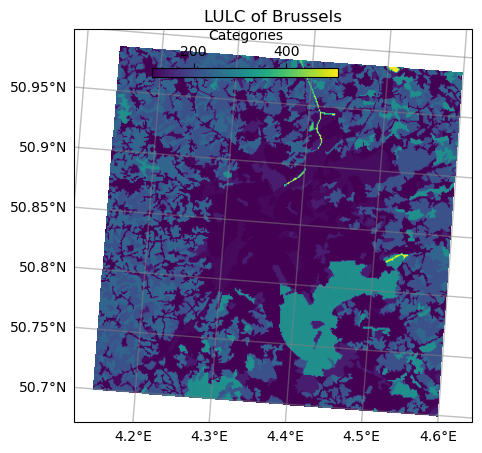

In [8]:
# Open the netCDF file
ncfile5 = netCDF4.Dataset('./data/meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_2015_06_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
extent_meteo3035 = [y.min(), y.max(), x.min(), x.max() ]
extent_meteo4326 = [lats.min(), lats.max(), lons.min(), lons.max() ]
print('extent_meteo3035: ',extent_meteo3035)
print('extent_meteo4326: ',extent_meteo4326)
ncfile5.close()

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/LULC/CLC_2012_brussels.tif')#probably not EPSG4326 doesn't match 
# Read the image data from the GeoTIFF file
image = src.read()[0]
print(src.crs)
print(src.width)
print(src.height)
extent_lulc4326 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print(extent_lulc4326)

clip_3035, clip, y_int, x_int = helpers.clip_city(extent_meteo3035, extent_meteo3035, 10) 
print('clip_3035',clip_3035)
#this clip is wrong. We need to calculate the correct clip with the clip_3035 we got from this step.
extent_meteo4326 = [extent_meteo4326[2], extent_meteo4326[3], extent_meteo4326[0], extent_meteo4326[1]]
print('extent_meteo4326',extent_meteo4326)

deg = 10001#interval in 1 degree
clip = [ int(np.floor((extent_lulc4326[3]-extent_meteo4326[3])*deg)), int(np.ceil((extent_lulc4326[3]-extent_meteo4326[2])*deg)),
        int(np.floor((extent_meteo4326[0]-extent_lulc4326[0])*deg)), int(np.ceil((extent_meteo4326[1]-extent_lulc4326[0])*deg))]
#clip = [1404, 4763, 2274, 6825]

print('clip',clip)
print('image.shape: ',image.shape)
data2 = image[clip[0]:clip[1], clip[2]:clip[3]]
print('data2.shape: ',data2.shape)

# Create a figure and axis with specified CRS
projection = ccrs.epsg(3035)
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(6, 6))

# Add coastlines and title
#ax.coastlines()
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
plt.title('LULC of Brussels')

# Add colorbar
im = ax.imshow(data2, extent=[extent_meteo4326[0], extent_meteo4326[1], extent_meteo4326[2],extent_meteo4326[3]], transform=ccrs.PlateCarree(), cmap='viridis', origin='upper')
plt.colorbar(im, ax=ax,location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8), label='Categories')
# Add coastlines
#ax.coastlines()
# Add gridlines with correct longitude and latitude markings
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Show the plot
plt.show()

In [32]:
# Open the netCDF file
ncfile5 = netCDF4.Dataset('./data/Meteorology/Brussels/Air_temp_brussels/tas_Brussels_UrbClim_2015_06_v1.0.nc',mode='r',format='NETCDF4_CLASSIC') 

x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
extent_meteo3035 = [y.min(), y.max(), x.min(), x.max() ]
extent_meteo4326 = [lats.min(), lats.max(), lons.min(), lons.max() ]
print('extent_meteo3035: ',extent_meteo3035)
print('extent_meteo4326: ',extent_meteo4326)
ncfile5.close()

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/LULC/CLC_2012_brussels.tif')#probably not EPSG4326 doesn't match 
# Read the image data from the GeoTIFF file
print(src.crs)
print(src.width)
print(src.height)
image = src.read()[0]
extent_lulc4326 = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]


clip_3035, clip, y_int, x_int = helpers.clip_city(extent_meteo3035, extent_meteo3035, 10) 
print('clip_3035',clip_3035)
#this clip is wrong. We need to calculate the correct clip with the clip_3035 we got from this step.
extent_meteo4326 = [extent_meteo4326[2], extent_meteo4326[3], extent_meteo4326[0], extent_meteo4326[1]]
print('extent_meteo4326',extent_meteo4326)
print('extent_lulc4326: ',extent_lulc4326)
deg = 10001#interval in 1 degree
clip = [ int(np.floor((extent_lulc4326[3]-extent_meteo4326[3])*deg)), int(np.ceil((extent_lulc4326[3]-extent_meteo4326[2])*deg)),
        int(np.floor((extent_meteo4326[0]-extent_lulc4326[0])*deg)), int(np.ceil((extent_meteo4326[1]-extent_lulc4326[0])*deg))]
#extent_meteo4326 [4.1430073, 4.6004033, 50.698475, 50.98796]
#extent_lulc4326:  [3.9999000000000002, 5.0, 50.499900000000004, 51.1011]
src.close()
print('clip', clip)#y.min, y.max, x.min, x.max
Ys_lulc4326, Xs_lulc4326 = helpers.GetCentroids(yLims=[src.bounds.bottom, src.bounds.top], xLims=[src.bounds.left, src.bounds.right], shapeYX=(src.height,src.width))
Ys_lulc3035, Xs_lulc3035 = helpers.GetGrids(yLims=[clip_3035[0], clip_3035[1]], xLims=[clip_3035[2], clip_3035[3]], shapeYX=(x_int,y_int))
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

# %%
map_classes = dict()

map_classes[0] = [111,112] #residential_area 
map_classes[1] = [121] #industrial/commercial_area
map_classes[2] = [122] #road/rail_transport
map_classes[3] = [123] #port
map_classes[4] = [124, 131, 132, 133] #airport, Mineral extraction sites, Dump sites and Construction sites
map_classes[5] = [141,142] #urban_green
map_classes[6] = [211, 212, 213, 221, 222, 223, 231, 241, 242, 243, 244] #cropland
map_classes[7] = [311, 312, 313] #forest
map_classes[8] = [321, 322, 323, 324] #shrub/grassland
map_classes[9] = [331, 332, 333, 334, 335] #bareland
map_classes[10] = [411, 412, 421, 422, 423] #wetland
map_classes[11] = [511, 512, 521, 522, 523] #waterbody
#map_classes[0]+map_classes[1]+map_classes[2]+map_classes[3]+map_classes[4] #total built-up
#map_classes[6]+map_classes[7]+map_classes[8]+map_classes[9]+map_classes[10]+map_classes[11] natural_areas
new_flag_values = np.arange(0,14).tolist()
# %%
new_classes = ['residential_area', 'industrial_commercial_area', 'road_rail_transport', 'port', 'other_artifical', 'urban_green', 
               'cropland', 'forest', 'shrub_grassland', 'bareland', 'wetland', 'waterbody', 'built-up', 'natural_areas']

lulc_nc = np.zeros((len(new_classes),y_int,x_int))
print(lulc_nc.shape)
Ys_lulc4326 = Ys_lulc4326[::-1]
Ys_lulc4326 = Ys_lulc4326[clip[0]-10:clip[1]+10]
Xs_lulc4326 = Xs_lulc4326[clip[2]-10:clip[3]+10]
print(Ys_lulc4326)
print(Xs_lulc4326)
print(Ys_lulc4326.shape)
print(Xs_lulc4326.shape)
image = image[clip[0]:clip[1], clip[2]:clip[3]]
print('image.shape',image.shape)

extent_meteo3035:  [3081555.0, 3111555.0, 3910061.0, 3940061.0]
extent_meteo4326:  [50.698475, 50.98796, 4.1430073, 4.6004033]
EPSG:4326
10001
6012
clip_3035 [3082000, 3111000, 3911000, 3940000]
extent_meteo4326 [4.1430073, 4.6004033, 50.698475, 50.98796]
extent_lulc4326:  [3.9999000000000002, 5.0, 50.499900000000004, 51.1011]
clip [1131, 4027, 1431, 6006]
(14, 29, 29)
[50.98895 50.98885 50.98875 ... 50.69765 50.69755 50.69745]
[4.14205 4.14215 4.14225 ... 4.60125 4.60135 4.60145]
(2916,)
(4595,)
image.shape (2896, 4575)


In [33]:
l=0
progress = image.shape[0]*image.shape[1] / 100
for y_4326 in Ys_lulc4326:

    for x_4326 in Xs_lulc4326:
        x_3035, y_3035 = transformer.transform(x_4326, y_4326)
        if y_3035 <= np.min(Ys_lulc3035) or y_3035 >= np.max(Ys_lulc3035) or x_3035 <= np.min(Xs_lulc3035) or x_3035 >= np.max(Xs_lulc3035):
            a=0
        else:
            l=l+1
            if l % progress == 0:
                print('Percentage',l / progress)
            y_index3035 = np.searchsorted(Ys_lulc3035, y_3035) - 1
            x_index3035 = np.searchsorted(Xs_lulc3035, x_3035) - 1
            y_index4326 = np.where(Ys_lulc4326 == y_4326)[0][0]
            x_index4326 = np.where(Xs_lulc4326 == x_4326)[0][0]

            #print('y_index4326,x_index4326: ',y_index4326,x_index4326)
            #print('image[y_index4326][x_index4326]: ',image[y_index4326][x_index4326])
            for key in map_classes:
                val = map_classes[key]
                for v in val:
                    if (v == image[y_index4326][x_index4326]):
                        lulc_nc[list(map_classes).index(key)][y_index3035, x_index3035] = lulc_nc[list(map_classes).index(key)][y_index3035, x_index3035]+1
                    else:
                        0==0

lulc = lulc_nc/np.sum(lulc_nc,axis=0)

Percentage 1.0
Percentage 2.0
Percentage 3.0
Percentage 4.0
Percentage 5.0
Percentage 6.0
Percentage 7.0
Percentage 8.0
Percentage 9.0
Percentage 10.0
Percentage 11.0
Percentage 12.0
Percentage 13.0
Percentage 14.0
Percentage 15.0
Percentage 16.0
Percentage 17.0
Percentage 18.0
Percentage 19.0
Percentage 20.0
Percentage 21.0
Percentage 22.0
Percentage 23.0
Percentage 24.0
Percentage 25.0
Percentage 26.0
Percentage 27.0
Percentage 28.0
Percentage 29.0
Percentage 30.0
Percentage 31.0
Percentage 32.0
Percentage 33.0
Percentage 34.0
Percentage 35.0
Percentage 36.0
Percentage 37.0
Percentage 38.0
Percentage 39.0
Percentage 40.0
Percentage 41.0
Percentage 42.0
Percentage 43.0
Percentage 44.0
Percentage 45.0
Percentage 46.0
Percentage 47.0
Percentage 48.0
Percentage 49.0
Percentage 50.0
Percentage 51.0
Percentage 52.0
Percentage 53.0
Percentage 54.0
Percentage 55.0
Percentage 56.0
Percentage 57.0
Percentage 58.0
Percentage 59.0
Percentage 60.0
Percentage 61.0
Percentage 62.0
Percentage 63.0
P

In [34]:
lulc[0]

array([[1.64597737e-01, 3.76817289e-01, 3.96511080e-01, 3.17560132e-01,
        3.94246640e-01, 1.30913091e-01, 0.00000000e+00, 1.94688875e-01,
        1.20924020e-01, 0.00000000e+00, 5.70261566e-02, 8.77583091e-01,
        7.65496111e-01, 6.94634300e-01, 1.00000000e+00, 6.34635028e-01,
        0.00000000e+00, 1.88987511e-01, 4.10854540e-01, 4.76115651e-01,
        6.92960402e-01, 1.00000000e+00, 9.03613511e-01, 6.06458202e-01,
        4.55416765e-01, 1.91358995e-01, 7.22025913e-01, 3.27362715e-01,
        1.70750864e-01],
       [2.98554368e-01, 5.67826565e-01, 6.20513626e-01, 4.60215223e-01,
        6.53420247e-01, 7.63647789e-01, 2.77825780e-01, 3.48837209e-01,
        6.79443877e-01, 2.93581585e-01, 4.19919881e-01, 9.24660225e-02,
        0.00000000e+00, 2.87150487e-01, 1.00000000e+00, 8.33058500e-01,
        3.53384640e-02, 9.51932139e-02, 6.09631550e-02, 2.10493245e-02,
        8.13555329e-01, 9.17713568e-01, 6.91600534e-01, 3.86506440e-01,
        6.79286780e-01, 6.11573492e-01,

In [35]:
lulc[12] = lulc[0]+lulc[1]+lulc[2]+lulc[3]+lulc[4] #total built-up
lulc[13] = lulc[6]+lulc[7]+lulc[8]+lulc[9]+lulc[10]+lulc[11] #natural_areas

In [41]:
lulc = lulc[:,::-1,:]
#map_classes[0]+map_classes[1]+map_classes[2]+map_classes[3]+map_classes[4] #total built-up
#map_classes[6]+map_classes[7]+map_classes[8]+map_classes[9]+map_classes[10]+map_classes[11] natural_areas

In [42]:
#creat grid indexes with centroid of the grids
y_new = np.array((np.arange(clip_3035[0]+500, clip_3035[1]+500, 1000)))[::-1]
x_new = np.array((np.arange(clip_3035[2]+500, clip_3035[3]+500, 1000)))
print(y_new)
print(y_new.shape)
print(x_new)
print(x_new.shape)
lons = np.zeros((y_new.shape[0], x_new.shape[0]))
lats = np.zeros((y_new.shape[0], x_new.shape[0]))
EPSG_from = 3035
EPSG_to = 4326
crs_from = pyproj.CRS('EPSG:'+str(EPSG_from))  # ETRS89 / LAEA Europe
crs_to = pyproj.CRS('EPSG:'+str(EPSG_to))    # WGS 84

# Create a transformer to convert coordinates
transformer = pyproj.Transformer.from_crs(crs_from, crs_to, always_xy=True)

for x in x_new:
    for y in y_new:
        x_loc = np.where(x_new==x)[0]
        y_loc = np.where(y_new==y)[0]
        lons[y_loc, x_loc], lats[len(y_new) - y_loc-1, x_loc] = transformer.transform(x, y)
#print(lons)
#print(lats)

[3110500 3109500 3108500 3107500 3106500 3105500 3104500 3103500 3102500
 3101500 3100500 3099500 3098500 3097500 3096500 3095500 3094500 3093500
 3092500 3091500 3090500 3089500 3088500 3087500 3086500 3085500 3084500
 3083500 3082500]
(29,)
[3911500 3912500 3913500 3914500 3915500 3916500 3917500 3918500 3919500
 3920500 3921500 3922500 3923500 3924500 3925500 3926500 3927500 3928500
 3929500 3930500 3931500 3932500 3933500 3934500 3935500 3936500 3937500
 3938500 3939500]
(29,)


(14, 29, 29)


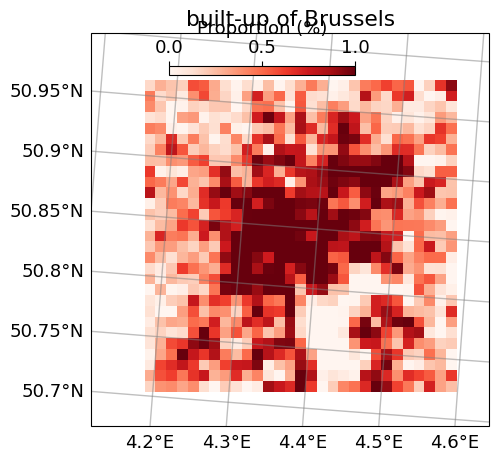

In [43]:
# Create a figure and axis with specified CRS
projection = ccrs.epsg(3035)
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(6, 6))
i=12

plt.title(new_classes[i] + ' of Brussels')
print(lulc.shape)

# Plot the data using pcolormesh
#Ys, Xs = helpers.GetCentroids(yLims=[clip_3035[0], clip_3035[1]], xLims=[clip_3035[2], clip_3035[3]], shapeYX=(clip_3035[1]- clip_3035[0],clip_3035[3]- clip_3035[2]))
#Ys = Ys[::-1]
plt.pcolormesh(x_new, y_new, lulc[i], cmap='Reds').set_clim(0,1)
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(label='Proportion (%)',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.7))


# Show the plot
plt.show()

In [44]:
#save the results in a nc file
OutputFile = netCDF4.Dataset('./data/LULC/CLC_2012_Brussels_14bands.nc', "w", format="NETCDF4")

len1 = OutputFile.createDimension("x", x_int)
len2 = OutputFile.createDimension("y", y_int)

y = y_new.copy()
x = x_new.copy()

var_x = OutputFile.createVariable("x", "f4", ("x",))
var_y = OutputFile.createVariable("y", "f4", ("y",))
var_lons = OutputFile.createVariable('longitude', "f4", ("y","x"))
var_lats = OutputFile.createVariable('latitude', "f4", ("y","x"))
for i in range(len(new_classes)):
    var = OutputFile.createVariable(new_classes[i], "f4", ("y","x"))
    var[:] = lulc[i]
    print(new_classes[i])

var_x[:] = x
var_y[:] = y
var_lons[:] = lons
var_lats[:] = lats
OutputFile.close()

residential_area
industrial_commercial_area
road_rail_transport
port
other_artifical
urban_green
cropland
forest
shrub_grassland
bareland
wetland
waterbody
built-up
natural_areas


In [39]:
lulc[5]+lulc[12]+lulc[13]

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1

In [11]:
CLC = ncfile5.variables['residential_area'][::-1,:].data
print(CLC.shape)

(29, 29)


(29, 29)
clip_3035 [3082000, 3111000, 3911000, 3940000]


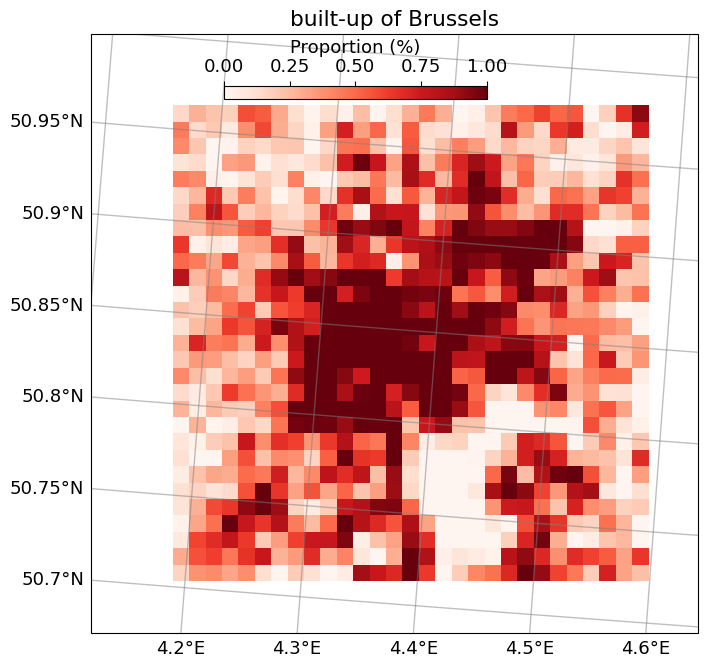

In [48]:
# Create a figure and axis with specified CRS
ncfile5 = netCDF4.Dataset('./data/LULC/CLC_2012_Brussels_14bands.nc',mode='r',format='NETCDF4_CLASSIC')

i=12 #5, 12, 13
new_classes = ['residential_area', 'industrial_commercial_area', 'road_rail_transport', 'port', 'other_artifical', 'urban_green', 
               'cropland', 'forest', 'shrub_grassland', 'bareland', 'wetland', 'waterbody', 'built-up', 'natural_areas']

LULC = ncfile5.variables[new_classes[i]][::].data
lons = ncfile5.variables['longitude'][:]
lats = ncfile5.variables['latitude'][:]
x = ncfile5.variables['x'][:]
y = ncfile5.variables['y'][:]
extent_3035 = [y.min()-500, y.max()+500, x.min()-500, x.max()+500 ]
ncfile5.close()

projection = ccrs.epsg(3035)
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(8.48, 9.15))
plt.rcParams.update({'font.size': 13})
plt.title(new_classes[i]+' of Brussels')
print(LULC.shape)
print('clip_3035',clip_3035)
clip_3035new = [clip_3035[0], clip_3035[1], clip_3035[2], clip_3035[3]]

# Plot the data using pcolormesh
plt.pcolormesh(x, y, LULC, cmap='Reds').set_clim(0,1)
ax.set_extent([4.12, 4.61, 50.695, 51], crs=ccrs.PlateCarree())
# Add coastlines and gridlines
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(label='Proportion (%)',location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.7))
ncfile5.close
plt.savefig('./data/Built-up.png', transparent=True, bbox_inches='tight', dpi=300)
# Show the plot
plt.show()

# Micro scale study start from here

In [1]:
import netCDF4
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rasterio
import pyproj

import helpers
import numpy as np

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/LULC/WorldCover_Brussels_clipped.tif')
# Read the image data from the GeoTIFF file
WorldCover = src.read()
#projection_tif = ccrs.epsg(src.crs.to_epsg())
# Get the extent of the image
extent_lulc = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print(extent_lulc)

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/DSM/DSM-DTM_50cm_vegetation_without_cars2.tif')
# Read the image data from the GeoTIFF file
vegetation = src.read()
#projection_tif = ccrs.epsg(src.crs.to_epsg())
# Get the extent of the image
extent_vegetation = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print(extent_vegetation)

# Overlay the GeoTIFF file on the map
src = rasterio.open('./data/DSM/DSM-DTM_50cm_building.tif')
# Read the image data from the GeoTIFF file
vegetation = src.read()[0]
#projection_tif = ccrs.epsg(src.crs.to_epsg())
# Get the extent of the image
extent_vegetation = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print(extent_vegetation)

src.close()

[140963.234, 158231.0647, 161258.9402, 178388.3314]
[140992.6341, 158203.6341, 161264.5716, 178375.5716]
[140992.6341, 158203.6341, 161264.5716, 178375.5716]


In [2]:
#0 Paved  for all 0 in building layer
#1 Buildings >0 in building layer
#2 Everygreen_trees vegetation >30
#3 Deciduous_trees  0.5 < vegetation < 30
#4 Grass 0 < vegetation < 0.5
#5 Bare_soil replace Paved Impermeables_extend*4 untill 0 
#6 Water lulc = water
new_classes = ['Paved', 'Buildings', 'Everygreen_trees', 'Deciduous_trees', 'Grass', 'Bare_soil', 'Water']
meter = 10 #prefered grid size
num = 5 #number of intervals on an axis
meter_0 = 0.5
factor = meter / meter_0
lulc_count = np.zeros((len(new_classes),int(round(vegetation.shape[0]/factor,0)),int(round(vegetation.shape[1]/factor,0))))
lulc_class = [10, 20, 30, 40, 50, 60, 70]
print(lulc_count.shape)

(7, 1711, 1721)


In [3]:
#WorldCover LULC as base map
file_list = ['./data/LULC/WorldCover_Brussels_clipped.tif']#, './data/DSM/DSM-DTM_50cm_vegetation_without_cars2.tif', './data/LULC/WorldCover_Brussels_clipped.tif']
#meter_0 = 0.5
#[Tree cover(10), Shrubland(20), Grassland(30), Cropland(40), Built-up(50), Bare / sparse vegetation(60), Snow and ice(70), Permanent water bodies(80), Herbaceous wetland(90), Mangroves(95), Moss and lichen(100)]
layers = [10, 20, 50, 60, 80]
for l in layers:
    src = rasterio.open(file_list[0])
    # Read the image data from the GeoTIFF file
    image = src.read()[0]
    if l ==10:
        image[image < l] = 0
        image[image==l] = 1 #Tree cover(10)
        image[image > l] = 0
    elif l ==20:   
        image[image < l] = 0
        image[image==l] = 1 #Shrubland(20)
        image[image==l+10] = 1 #Grassland(30)
        image[image==l+20] = 1 #Cropland(40)
        image[image > l+20] = 0
    if l ==50:
        image[image < l] = 0
        image[image==l] = 1 #Built-up(50)
        image[image > l] = 0
    elif l ==60:   
        image[image < l] = 0
        image[image==l] = 1 #Bare / sparse vegetation(60)
        image[image==l+10] = 1 #Snow and ice(70)
        image[image > l+10] = 0
        image[image==l+40] = 1 #Moss and lichen(100)
    elif l ==80:   
        image[image < l] = 0
        image[image==l] = 1 #Permanent water bodies(80)
        image[image==l+10] = 1 #Herbaceous wetland(90)
        image[image==l+15] = 1 #Mangroves(95)
        image[image > l+15] = 0
    
    print('image.shape: ', image.shape)
    image = np.repeat(image, 9, axis = 0)
    image = np.repeat(image, 6, axis = 1)
    image = helpers.up_scale(image, 2)
    print('image.shape: ', image.shape)
    
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            y_in = int(np.floor(y / num / 0.972))
            x_in = int(np.floor(x / num / 1.026))
            if image[y, x] > 0.5:
                if l == 10:
                    lulc_count[3][y_in, x_in] = lulc_count[3][y_in, x_in] + 1
                elif l == 20:
                    lulc_count[4][y_in, x_in] = lulc_count[4][y_in, x_in] + 1
                elif l == 50:
                    lulc_count[0][y_in, x_in] = lulc_count[0][y_in, x_in] + 1
                elif l == 60:
                    lulc_count[5][y_in, x_in] = lulc_count[5][y_in, x_in] + 1
                elif l == 80:
                    lulc_count[6][y_in, x_in] = lulc_count[6][y_in, x_in] + 1
            else: 
                0==0
    
            

image.shape:  (1848, 2941)
image.shape:  (8316, 8823)
image.shape:  (1848, 2941)
image.shape:  (8316, 8823)
image.shape:  (1848, 2941)
image.shape:  (8316, 8823)
image.shape:  (1848, 2941)
image.shape:  (8316, 8823)
image.shape:  (1848, 2941)
image.shape:  (8316, 8823)


In [4]:
#replace paved with buildings
#0 Paved  for all 0 in building layer
#1 Buildings >0 in building layer
file_list = ['./data/DSM/DSM-DTM_50cm_building.tif']#, './data/DSM/DSM-DTM_50cm_vegetation_without_cars2.tif', './data/LULC/WorldCover_Brussels_clipped.tif']
meter_0 = 0.5
for f in file_list:
    src = rasterio.open(f)
    # Read the image data from the GeoTIFF file
    image = src.read()[0]
    image[image > 0] = 1 #set as 0, 1 
    factor = int(meter / num / meter_0)
    image = helpers.up_scale(image, factor)
    print('image.shape: ', image.shape)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            y_in = int(np.floor(y / num))
            x_in = int(np.floor(x / num))
            if image[y, x] > 0.5:
                lulc_count[1][y_in, x_in] = lulc_count[1][y_in, x_in] + 1
                if lulc_count[0][y_in, x_in] > 0:
                    lulc_count[0][y_in, x_in] = lulc_count[0][y_in, x_in] - 1

                
            

image.shape:  (8555, 8605)


(7, 1711, 1721)


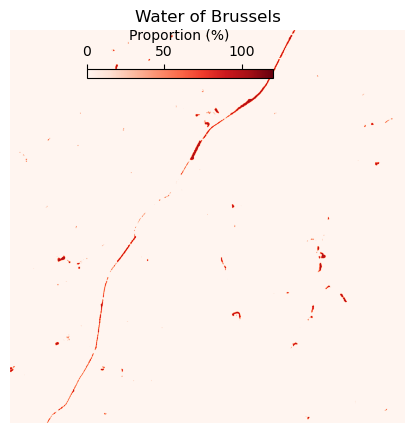

In [100]:
projection = ccrs.epsg(3035)
print(lulc_count.shape)
i = 6
fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(6, 6))
im = ax.imshow(lulc_count[i]*4, cmap='Reds', origin='upper')
plt.colorbar(im, ax=ax,location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8), label='Proportion (%)')
plt.title(new_classes[i] + ' of Brussels')

# Show the plot
plt.show()

In [6]:
#add permeables in the urban areas as bare soil and reduce the represention of WorldCover in urban area

file_list = ['./data/3D_city/Impermeables_extend.tif']#, , './data/LULC/WorldCover_Brussels_clipped.tif']
meter_0 = 1
for f in file_list:
    src = rasterio.open(f)
    # Read the image data from the GeoTIFF file
    image = src.read()[0]
    src = rasterio.open('./data/DSM/DSM_50cm_ground_building2.tif')
    nan = src.read()[0]
    nan = helpers.up_scale(nan, 2)
    
    image[nan < 0] = 1 #focus on urban area 
    image[image < 0] = 0 #set as 0, 1
    factor = int(meter / num / meter_0)
    image = helpers.up_scale(image, factor)
    print('image.shape: ', image.shape)
    '''
    fig, ax = plt.subplots(subplot_kw={'projection': projection},figsize=(6, 6))
    plt.colorbar(im, ax=ax,location='top', orientation='horizontal', shrink=0.4, pad=0, anchor=(0.4, -0.8), label='Proportion (%)')
    im = ax.imshow(image, cmap='Reds', origin='upper')
    plt.show()
    
    '''
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            y_in = int(np.floor(y / num))
            x_in = int(np.floor(x / num))
            if image[y, x] < 0.5:
                if lulc_count[6][y_in, x_in] <= 0: #keep water
                    if lulc_count[4][y_in, x_in] <= 0: #keep grass
                        lulc_count[5][y_in, x_in] = lulc_count[5][y_in, x_in] + 1


                


image.shape:  (8555, 8605)


In [7]:
lulc_count = lulc_countCOPY.copy()

In [8]:
# vegetations

#0 Paved  for all 0 in building layer
#1 Buildings >0 in building layer
#2 Everygreen_trees vegetation >30
#3 Deciduous_trees  0.5 < vegetation < 30
#4 Grass 0 < vegetation < 0.5
#5 Bare_soil replace Paved Impermeables_extend*4 untill 0 
#6 Water lulc = water
file_list = ['./data/DSM/DSM-DTM_50cm_vegetation_without_cars2.tif']#, , './data/LULC/WorldCover_Brussels_clipped.tif']
#lulc_count = np.zeros((len(new_classes),int(round(vegetation.shape[1]/20,0)),int(round(vegetation.shape[2]/20,0))))
print('lulc_count.shape: ', lulc_count.shape)
meter_0 = .5
for f in file_list:
    src = rasterio.open(f)
    # Read the image data from the GeoTIFF file
    image = src.read()[0]
    
    factor = int(meter / num / meter_0)
    image = helpers.up_scale(image, factor)
    print('image.shape: ', image.shape)

    image[image < 0.1] = 1000 #no vegetation
    image[image < 1] = 2000 #grass
    image[image < 27] = 3000 #Deciduous_trees
    image[image < 40] = 4000 #Everygreen_trees
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            y_in = int(np.floor(y / num))
            x_in = int(np.floor(x / num))
            if image[y, x] ==1000: #paved, buildings, bare_soil, grass or water
                if lulc_count[5][y_in, x_in] > 0:  
                    if lulc_count[0][y_in, x_in] > 0: #paved for WorldCover but bare_soil for Impermeables and Vegetation
                        lulc_count[0][y_in, x_in] = lulc_count[0][y_in, x_in] - 1
                    elif lulc_count[3][y_in, x_in] > 0: #Deciduous_trees for WorldCover but bare_soil for Impermeables and Vegetation
                        lulc_count[3][y_in, x_in] = lulc_count[3][y_in, x_in] - 0.75

            elif image[y, x] ==2000: #grass
                if lulc_count[0][y_in, x_in] > 0: #replace paved by grass
                    if lulc_count[5][y_in, x_in] > 0:
                        lulc_count[0][y_in, x_in] = lulc_count[0][y_in, x_in] - 1
                        lulc_count[4][y_in, x_in] = lulc_count[4][y_in, x_in] + 1
                if lulc_count[5][y_in, x_in] > 0: #replace bare_soil 
                    lulc_count[5][y_in, x_in] = lulc_count[5][y_in, x_in] - 0.9
            elif image[y, x] ==3000:#Deciduous_trees
                if lulc_count[0][y_in, x_in] > 0:#replace paved by Deciduous_trees
                    if lulc_count[5][y_in, x_in] > 0:
                        lulc_count[0][y_in, x_in] = lulc_count[0][y_in, x_in] - 1
                        lulc_count[3][y_in, x_in] = lulc_count[3][y_in, x_in] + 1
                if lulc_count[5][y_in, x_in] > 0: #replace bare_soil 
                    lulc_count[5][y_in, x_in] = lulc_count[5][y_in, x_in] - 0.9
            elif image[y, x] ==4000: #Everygreen_trees
                if lulc_count[3][y_in, x_in] > 0:#replace Deciduous_trees by  Everygreen_trees
                    lulc_count[3][y_in, x_in] = lulc_count[3][y_in, x_in] - 1
                    lulc_count[2][y_in, x_in] = lulc_count[2][y_in, x_in] + 1
                if lulc_count[0][y_in, x_in] > 0:#replace paved by  Everygreen_trees
                    if lulc_count[5][y_in, x_in] > 0:
                        lulc_count[0][y_in, x_in] = lulc_count[0][y_in, x_in] - 1
                        lulc_count[2][y_in, x_in] = lulc_count[2][y_in, x_in] + 1
                if lulc_count[5][y_in, x_in] > 0: #replace bare_soil 
                    lulc_count[5][y_in, x_in] = lulc_count[5][y_in, x_in] - 0.9

lulc_count.shape:  (7, 1711, 1721)
image.shape:  (8555, 8605)


In [9]:
lulc_nc = lulc_count.copy()
lulc_nc[:, :, 0] = lulc_nc[:, :, 2]
lulc_nc[:, :, 1] = lulc_nc[:, :, 2] 

lulc_nc[:, :, -1] = lulc_nc[:, :, -5]
lulc_nc[:, :, -2] = lulc_nc[:, :, -5] 
lulc_nc[:, :, -3] = lulc_nc[:, :, -5] 
lulc_nc[:, :, -4] = lulc_nc[:, :, -5]

lulc_nc[:, 0, :] = lulc_nc[:, 1, :]

lulc_nc[:, -1, :] = lulc_nc[:, -2, :]

#print(np.sum(lulc_count, axis = 0))
lulc_nc = lulc_nc / np.sum(lulc_nc, axis = 0)

In [18]:
lulc_nc[:, 95, 1080]

array([nan, nan, nan, nan, nan, nan, nan])

In [10]:
output_data = np.zeros([lulc_count.shape[1], lulc_count.shape[2]], dtype=np.uint8)
for i in range(lulc_count.shape[1]):
    for j in range(lulc_count.shape[2]):
        #print(i,j)
        output_data[i,j] = np.where(lulc_nc[:,i,j]==np.max(lulc_nc[:,i,j]))[0][0]
output_data = output_data + 1

In [11]:
# Write the  raster
file_list = ['./data/DSM/DSM-DTM_50cm_building.tif']#, './data/DSM/DSM-DTM_50cm_vegetation_without_cars2.tif', './data/LULC/WorldCover_Brussels_clipped.tif']
meter_0 = 0.5
for f in file_list:
    src = rasterio.open(f)
    kwargs = src.meta.copy()
    print(kwargs)
src.close()
output_raster = './data/LULC/LULC_UMEP3.tif'
meta = kwargs.copy()
print(meta)
meta.update({
                 'width':output_data.shape[1],
                 'height':output_data.shape[0],
                 'dtype':'uint8',
                 'nodata':0,
                 'transform': rasterio.Affine(10, 0.0, 140992.6341, 0.0, -10, 178375.5716)
                  })
print(meta)
with rasterio.open(output_raster, 'w', **meta) as dest:
    dest.write(output_data.astype(rasterio.uint8), 1)
dest.close

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.4028234663852886e+38, 'width': 34422, 'height': 34222, 'count': 1, 'crs': CRS.from_epsg(31370), 'transform': Affine(0.5, 0.0, 140992.6341,
       0.0, -0.5, 178375.5716)}
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.4028234663852886e+38, 'width': 34422, 'height': 34222, 'count': 1, 'crs': CRS.from_epsg(31370), 'transform': Affine(0.5, 0.0, 140992.6341,
       0.0, -0.5, 178375.5716)}
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0, 'width': 1721, 'height': 1711, 'count': 1, 'crs': CRS.from_epsg(31370), 'transform': Affine(10.0, 0.0, 140992.6341,
       0.0, -10.0, 178375.5716)}


<bound method DatasetBase.close of <closed DatasetWriter name='./data/LULC/LULC_UMEP3.tif' mode='w'>>